In [3]:
import numpy as np
import pandas as pd
import time
import lazy_3d_1 as tc
from PSO_1 import pso_optimization


In [4]:
node = pd.read_excel("Connectivity data.xlsx", sheet_name="node", header=None)
mem = pd.read_excel("Connectivity data.xlsx",sheet_name="con", header=None)


a = time.time()

E = 2.10e11  # Young's modulus in Pa
ρ = 7850  # Density in kg/m^3
xFac = 10
#np.random.seed(42) 

nodes = node.to_numpy()


members = mem.to_numpy()

symmetry_groups = [ ]

restrainedDoF = [1, 2, 3, 7, 8, 9, 16, 17, 18, 19, 20, 21]

load_case_1 = np.zeros(60)
load_case_2 = np.zeros(60)
load_case_3 = np.zeros(60)


# 2. Define a Helper Function
def add_load(force_vector, node_number, direction, value):
    """
    node_number: Engineering number (starts at 1)
    direction: 'x', 'y', or 'z'
    value: Force amount
    """
    # 1. Convert Node to 0-based index start
    base_index = (node_number - 1) * 3
    
    # 2. Add offset for direction
    if direction.lower() == 'x':
        idx = base_index
    elif direction.lower() == 'y':
        idx = base_index + 1
    elif direction.lower() == 'z':
        idx = base_index + 2
    else:
        raise ValueError("Direction must be x, y, or z")
        
    # 3. Apply load
    if idx >= len(force_vector):
        print(f"Error: Node {node_number} is out of bounds!")
        return
        
    force_vector[idx] += value # Use += to allow adding multiple loads to same node


# 3. Apply your loads effortlessly
add_load(load_case_1, 18, 'z', -10000) #Put in correct load case and load direction
add_load(load_case_1, 19, 'z', -10000) #Gravity Loading
add_load(load_case_1, 20, 'z', -10000) 
add_load(load_case_1, 17, 'z', -10000) 

add_load(load_case_2, 2, 'x', 5000) #Wind Loading
add_load(load_case_2, 4, 'x', 5000)
add_load(load_case_2, 9, 'x', 5000) 
add_load(load_case_2, 10, 'x', 5000)
add_load(load_case_2, 13, 'x', 5000)
add_load(load_case_2, 14, 'x', 5000)
add_load(load_case_2, 17, 'x', 5000)
add_load(load_case_2, 18, 'x', 5000)

add_load(load_case_3, 18, 'z', -10000) #Combined Loading
add_load(load_case_3, 19, 'z', -10000) 
add_load(load_case_3, 20, 'z', -10000) 
add_load(load_case_3, 17, 'z', -10000) 
add_load(load_case_3, 2, 'x', 5000) 
add_load(load_case_3, 4, 'x', 5000)
add_load(load_case_3, 9, 'x', 5000) 
add_load(load_case_3, 10, 'x', 5000)
add_load(load_case_3, 13, 'x', 5000)
add_load(load_case_3, 14, 'x', 5000)
add_load(load_case_3, 17, 'x', 5000)
add_load(load_case_3, 18, 'x', 5000)




forceVectors = [load_case_1, load_case_2, load_case_3]




A_min = 5 # Minimum cross-sectional area in  cm^2
A_max = 129.03 # Maximum cross-sectional area in  cm^2
sigma_max = 240e6  # Maximum allowable stress in Pa
delta_max = 5e-3 # Maximum allowable displacement in m

f_min_list = [4] 

n_particles = 500
n_iterations = 500
w = 0.9
c1 = 2
c2 = 2

final_weights = []
optimal_areas = []
all_best_scores = [] 

for run in range(1):
    print(f"Run {run + 1}/100")
    global_best_position, final_weight, best_scores = pso_optimization(
        n_particles, n_iterations, c1, c2, E, ρ, xFac, nodes, members, restrainedDoF, forceVectors,
        A_min, A_max, sigma_max, delta_max, f_min_list,symmetry_groups=None, stress=True, displacement=True, buckling=True, tolerance=1e-6 
    )
    final_weights.append(final_weight)
    optimal_areas.append(global_best_position)
    all_best_scores.append(best_scores) 

min_weight_index = np.argmin(final_weights)
best_run_scores = all_best_scores[min_weight_index]
best_areas = optimal_areas[min_weight_index]

print(f"Final optimized weight: {final_weights[min_weight_index]:.4f}")
print("\nOptimal member areas (corresponding to minimum weight):",best_areas)



b = time.time()
print("Total time required: ", b - a, " sec")




Run 1/100


PSO Optimization Progress: 100%|██████████| 500/500 [20:16<00:00,  2.43s/it]

Final optimized weight: 876.5753

Optimal member areas (corresponding to minimum weight): [ 5.          5.          5.          5.          5.          5.
  5.          5.          6.90135579  5.          5.          5.
  5.          5.          5.          5.          5.          5.
  5.          9.11416776  5.          5.          5.          5.
  5.          5.          5.         11.01077852  5.          5.
  5.          5.          5.          5.          5.          5.
  5.          5.          5.          5.          5.          5.
  5.          5.          5.          5.          5.          5.
  5.          5.          5.          5.          5.          5.
  5.          5.          5.          5.          5.          5.
  5.          5.          5.          5.          5.          5.
  5.          5.          5.          5.          5.          5.        ]
Total time required:  1216.518123626709  sec


In [5]:
mean_weight = np.mean(final_weights)
std_weight = np.std(final_weights)
print(mean_weight)
print(std_weight)

876.5753052159407
0.0


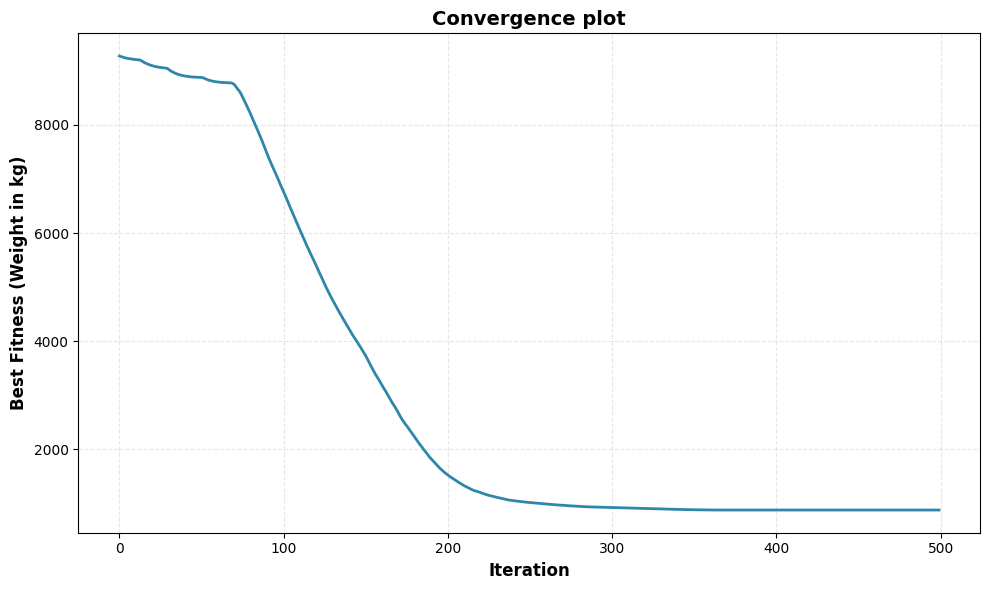

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.plot(best_run_scores, linewidth=2, color='#2E86AB')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Best Fitness (Weight in kg)', fontsize=12, fontweight='bold')
plt.title("Convergence plot", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

INDEPENDENT CONSTRAINT VERIFICATION

Structure Weight: 876.5753 kg
Number of Members: 72
Number of Load Cases: 3

Member Areas (cm²):
--------------------------------------------------------------------------------
  Member 1: 5.00 cm²
  Member 2: 5.00 cm²
  Member 3: 5.00 cm²
  Member 4: 5.00 cm²
  Member 5: 5.00 cm²
  Member 6: 5.00 cm²
  Member 7: 5.00 cm²
  Member 8: 5.00 cm²
  Member 9: 6.90 cm²
  Member 10: 5.00 cm²
  Member 11: 5.00 cm²
  Member 12: 5.00 cm²
  Member 13: 5.00 cm²
  Member 14: 5.00 cm²
  Member 15: 5.00 cm²
  Member 16: 5.00 cm²
  Member 17: 5.00 cm²
  Member 18: 5.00 cm²
  Member 19: 5.00 cm²
  Member 20: 9.11 cm²
  Member 21: 5.00 cm²
  Member 22: 5.00 cm²
  Member 23: 5.00 cm²
  Member 24: 5.00 cm²
  Member 25: 5.00 cm²
  Member 26: 5.00 cm²
  Member 27: 5.00 cm²
  Member 28: 11.01 cm²
  Member 29: 5.00 cm²
  Member 30: 5.00 cm²
  Member 31: 5.00 cm²
  Member 32: 5.00 cm²
  Member 33: 5.00 cm²
  Member 34: 5.00 cm²
  Member 35: 5.00 cm²
  Member 36: 5.00 cm²
 

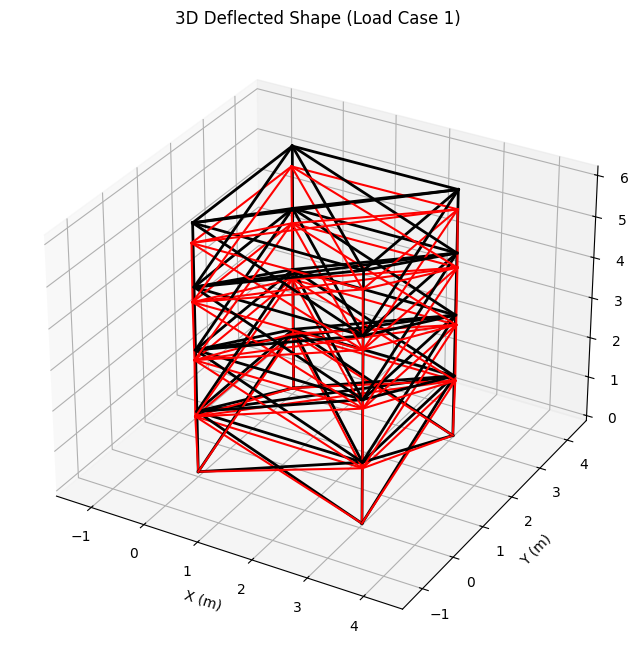

In [10]:
import numpy as np
import pandas as pd
import lazy_3d_1 as tc

def verify_design_constraints(
    optimized_areas_cm2,
    E, ρ, xFac, nodes, members, restrainedDoF, forceVectors,
    Fy, delta_max, symmetry_groups=None, verbose=True
):
    """
    Independent verification of optimized truss design against all constraints.
    
    Parameters:
    -----------
    optimized_areas_cm2 : array-like
        Cross-sectional areas in cm² (either per member or per symmetry group)
    E : float
        Young's modulus (Pa)
    ρ : float
        Density (kg/m³)
    xFac : float
        Displacement scaling factor for visualization
    nodes : array
        Node coordinates
    members : array
        Member connectivity
    restrainedDoF : list
        Restrained degrees of freedom
    forceVectors : list
        Load cases
    Fy : float
        Yield strength (Pa)
    delta_max : float
        Maximum allowable displacement (m)
    symmetry_groups : list, optional
        Symmetry groups if areas are grouped
    verbose : bool
        Print detailed results
    
    Returns:
    --------
    dict : Verification results including pass/fail status
    """
    
    # Map areas to members
    if symmetry_groups is None:
        # Areas are per member
        member_areas_m2 = np.array(optimized_areas_cm2) / 1e4
    else:
        # Areas are per symmetry group
        member_areas_m2 = np.zeros(len(members))
        for group_idx, group in enumerate(symmetry_groups):
            for member_idx in group:
                member_areas_m2[member_idx - 1] = optimized_areas_cm2[group_idx] / 1e4
    
    # Create truss analysis object
    truss = tc.TrussAnalysis3D(
        E, member_areas_m2, ρ, xFac, nodes, members,
        restrainedDoF, forceVectors
    )
    
    # Calculate weight
    weight = truss.calculate_weight()
    
    # Get all analysis results
    _, UG_all, FG_all, mbrForces_all, stresses_all = truss.get_stress_displacement_forces()
    
    # Initialize results dictionary
    results = {
        'weight_kg': weight,
        'member_areas_cm2': member_areas_m2 * 1e4,
        'load_cases': [],
        'overall_pass': True
    }
    
    if verbose:
        print("=" * 80)
        print("INDEPENDENT CONSTRAINT VERIFICATION")
        print("=" * 80)
        print(f"\nStructure Weight: {weight:.4f} kg")
        print(f"Number of Members: {len(members)}")
        print(f"Number of Load Cases: {len(forceVectors)}")
        print(f"\nMember Areas (cm²):")
        print("-" * 80)
    
    # Display member areas
    if verbose:
        if symmetry_groups and len(symmetry_groups) < len(members):
            for group_idx, group in enumerate(symmetry_groups):
                area_cm2 = optimized_areas_cm2[group_idx]
                print(f"  Group {group_idx + 1} (Members {group}): {area_cm2:.2f} cm²")
        else:
            for i, area in enumerate(member_areas_m2 * 1e4):
                print(f"  Member {i + 1}: {area:.2f} cm²")
    
    # Check each load case
    for load_case_idx, (mbrForces, UG, stresses) in enumerate(zip(mbrForces_all, UG_all, stresses_all)):
        if verbose:
            print(f"\n{'=' * 80}")
            print(f"LOAD CASE {load_case_idx + 1}")
            print("=" * 80)
        
        load_case_results = {
            'load_case': load_case_idx + 1,
            'displacement_check': {},
            'stress_check': {},
            'aisc_check': {}
        }
        
        # 1. DISPLACEMENT CHECK
        max_displacement = np.max(np.abs(UG))
        displacement_pass = max_displacement <= delta_max
        displacement_ratio = max_displacement / delta_max
        
        load_case_results['displacement_check'] = {
            'max_displacement_m': max_displacement,
            'allowable_m': delta_max,
            'ratio': displacement_ratio,
            'pass': displacement_pass
        }
        
        if verbose:
            print(f"\n1. DISPLACEMENT CHECK")
            print("-" * 80)
            print(f"   Max Displacement: {max_displacement*1000:.4f} mm")
            print(f"   Allowable:        {delta_max*1000:.4f} mm")
            print(f"   Utilization:      {displacement_ratio*100:.2f}%")
            status = "✓ PASS" if displacement_pass else "✗ FAIL"
            print(f"   Status:           {status}")
        
        if not displacement_pass:
            results['overall_pass'] = False
        
        # 2. SIMPLE STRESS CHECK (for reference)
        max_stress = np.max(np.abs(stresses))
        sigma_allowable_simple = 0.6 * Fy  # Simple allowable
        stress_pass_simple = max_stress <= sigma_allowable_simple
        stress_ratio_simple = max_stress / sigma_allowable_simple
        
        load_case_results['stress_check'] = {
            'max_stress_Pa': max_stress,
            'max_stress_MPa': max_stress / 1e6,
            'allowable_Pa': sigma_allowable_simple,
            'ratio': stress_ratio_simple,
            'pass': stress_pass_simple
        }
        
        if verbose:
            print(f"\n2. SIMPLE STRESS CHECK (0.6*Fy)")
            print("-" * 80)
            print(f"   Max Stress:       {max_stress/1e6:.2f} MPa")
            print(f"   Allowable:        {sigma_allowable_simple/1e6:.2f} MPa")
            print(f"   Utilization:      {stress_ratio_simple*100:.2f}%")
            status = "✓ PASS" if stress_pass_simple else "✗ FAIL"
            print(f"   Status:           {status}")
        
        # 3. AISC CONSTRAINT CHECK (Most comprehensive)
        aisc_violation = truss.calculate_aisc_constraints(Fy)
        aisc_pass = aisc_violation <= 0
        
        load_case_results['aisc_check'] = {
            'violation_Pa': aisc_violation,
            'violation_MPa': aisc_violation / 1e6,
            'pass': aisc_pass
        }
        
        if verbose:
            print(f"\n3. AISC DESIGN CHECK (Tension + Buckling)")
            print("-" * 80)
            if aisc_pass:
                print(f"   Status:           ✓ PASS")
                print(f"   All members satisfy AISC requirements")
            else:
                print(f"   Status:           ✗ FAIL")
                print(f"   Max Violation:    {aisc_violation/1e6:.2f} MPa")
                print(f"   Some members exceed AISC capacity")
        
        if not aisc_pass:
            results['overall_pass'] = False
        
        # 4. MEMBER-BY-MEMBER ANALYSIS (if requested)
        if verbose:
            print(f"\n4. CRITICAL MEMBERS ANALYSIS")
            print("-" * 80)
            
            # Find most stressed members
            stress_ratios = np.abs(stresses) / sigma_allowable_simple
            critical_indices = np.argsort(stress_ratios)[-5:][::-1]  # Top 5
            
            print(f"   Top 5 Most Stressed Members:")
            print(f"   {'Member':<10} {'Force (kN)':<15} {'Stress (MPa)':<15} {'Util %':<10} {'Type':<10}")
            print(f"   {'-'*70}")
            
            for idx in critical_indices:
                force_kN = mbrForces[idx] / 1000
                stress_MPa = stresses[idx] / 1e6
                util = stress_ratios[idx] * 100
                mem_type = "Tension" if stresses[idx] > 0 else "Compression"
                print(f"   {idx+1:<10} {force_kN:>14.2f} {stress_MPa:>14.2f} {util:>9.2f} {mem_type:<10}")
        
        results['load_cases'].append(load_case_results)
    
    # FINAL SUMMARY
    if verbose:
        print(f"\n{'=' * 80}")
        print("FINAL VERIFICATION SUMMARY")
        print("=" * 80)
        print(f"Structure Weight:     {weight:.4f} kg")
        
        all_displacement_pass = all(lc['displacement_check']['pass'] for lc in results['load_cases'])
        all_stress_pass = all(lc['stress_check']['pass'] for lc in results['load_cases'])
        all_aisc_pass = all(lc['aisc_check']['pass'] for lc in results['load_cases'])
        
        print(f"\nDisplacement Check:   {'✓ PASS' if all_displacement_pass else '✗ FAIL'}")
        print(f"Simple Stress Check:  {'✓ PASS' if all_stress_pass else '✗ FAIL'}")
        print(f"AISC Design Check:    {'✓ PASS' if all_aisc_pass else '✗ FAIL'}")
        
        print(f"\n{'=' * 80}")
        if results['overall_pass']:
            print("OVERALL RESULT: ✓ DESIGN IS FEASIBLE")
        else:
            print("OVERALL RESULT: ✗ DESIGN FAILS CONSTRAINTS")
        print("=" * 80)
    
    return results, truss


# After your optimization completes:
best_areas = optimal_areas[min_weight_index]  # Your optimized areas in cm²

# Run independent verification:
results, truss = verify_design_constraints(
    optimized_areas_cm2=best_areas,
    E=2.10e11,
    ρ=7850,
    xFac=1000,
    nodes=nodes,
    members=members,
    restrainedDoF=[1, 2, 3, 7, 8, 9, 16, 17, 18, 19, 20, 21],
    forceVectors=forceVectors,
    Fy=400e6,
    delta_max=5e-3,
    symmetry_groups=None,  # Set to your groups if you used them
    verbose=True
)

# Check if design passes:
if results['overall_pass']:
    print("✓ Design is feasible!")
    truss.plot_deflected_shape(load_case=0)
else:
    print("✗ Design fails - check output above")



In [8]:
truss.summary_output()

--------------------------------------------------
3D STATIC STRUCTURAL ANALYSIS SUMMARY
--------------------------------------------------

>>> LOAD CASE 1 <<<

--- REACTIONS ---
Node 1 (X): 1.32 kN
Node 1 (Y): 1.15 kN
Node 1 (Z): 9.69 kN
Node 3 (X): -1.31 kN
Node 3 (Y): 1.21 kN
Node 3 (Z): 10.31 kN
Node 6 (X): -1.16 kN
Node 6 (Y): -1.21 kN
Node 6 (Z): 9.69 kN
Node 7 (X): 1.15 kN
Node 7 (Y): -1.15 kN
Node 7 (Z): 10.31 kN

--- MEMBER FORCES ---
Member 1: 8.45 kN (C)
Member 2: 9.05 kN (C)
Member 3: 1.20 kN (T)
Member 4: 1.01 kN (T)
Member 5: 8.51 kN (C)
Member 6: 9.16 kN (C)
Member 7: 1.19 kN (T)
Member 8: 1.19 kN (T)
Member 9: 1.47 kN (C)
Member 10: 1.47 kN (C)
Member 11: 1.35 kN (C)
Member 12: 1.36 kN (C)
Member 13: 1.17 kN (T)
Member 14: 1.13 kN (T)
Member 15: 1.28 kN (C)
Member 16: 1.29 kN (C)
Member 17: 1.29 kN (C)
Member 18: 1.29 kN (C)
Member 19: 8.92 kN (C)
Member 20: 9.65 kN (C)
Member 21: 0.92 kN (T)
Member 22: 0.85 kN (T)
Member 23: 8.97 kN (C)
Member 24: 9.46 kN (C)
Member 2